### Lets do a tour analysis based on the clusters we got

In [1]:
import gc
import pandas as pd
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent
journey_path = BASE_DIR / "data/clean/journey_clusters.csv"

In [3]:
journey_stats = pd.read_csv(journey_path)

In [4]:
journey_stats = journey_stats.drop(columns=["Unnamed: 0"])

In [5]:
journey_raw = journey_stats.copy()

In [7]:
tour_path = BASE_DIR / "data/clean/tour_info.csv"

In [8]:
tour_info = pd.read_csv(tour_path)

In [9]:
tour_info.head(10)

,Unnamed: 0,tour_id,tour_name,tour_length,total_stories
0,0,51,Ancient Agora: the birth of democracy,140.0,113
1,1,55,National Archaeological Museum: the notable Gr...,100.0,82
2,2,79,The curious Oltrarno,NaN,19
3,3,86,"Delphi and Iera Chora, the steps of Parnassus",180.0,13
4,4,91,Piraeus: Hidden urban stories,110.0,51
5,5,107,﻿Knossos: Daily Life in the Minoan Era,100.0,220
6,6,121,On the prowl: the cats of Athens,30.0,30
7,7,126,Find your (queer) god in Mykonos,100.0,20
8,8,139,Delphi: the Google of the ancient world-old,50.0,60
9,9,141,Mani: The gates of Hades,NaN,20


In [10]:
journey_stats.head(10)

,journey_id,user_pseudo_id,tour_id,distinct_stories_touched,distinct_stories_completed,total_times_completed,max_story_completed_position,dropoff_position,total_stories,depth_ratio,...,completed_sequential_transitions,sequential_completed_ratio,distinct_sequential_transitions,distinct_completed_sequential_transitions,max_possible_transitions,global_sequential_coverage,global_completed_sequential_coverage,interactivity_pct,pct_touched,cluster
0,12146,c7f26129dd892cb7292f6283113726ad,107,67.0,11.0,12,167.0,220.0,220.0,0.050000,...,8,0.098765,59.0,6.0,219.0,0.269406,0.027397,0.019704,0.304545,0
1,840,0e1e29466bf2de31e00fe7a989673c99,822,2.0,1.0,1,2.0,2.0,82.0,0.012195,...,0,0.000000,0.0,0.0,81.0,0.000000,0.000000,0.000000,0.024390,2
2,841,0e1e29466bf2de31e00fe7a989673c99,822,48.0,23.0,28,81.0,82.0,82.0,0.280488,...,33,0.275000,30.0,15.0,81.0,0.370370,0.185185,0.086364,0.585366,2
3,7295,767fa15a9558b669f47d8e67e719918c,284,41.0,16.0,17,63.0,64.0,67.0,0.238806,...,3,0.027273,13.0,2.0,66.0,0.196970,0.030303,0.076923,0.611940,0
4,10605,ada97a097eabb072201591dd267767cd,447,4.0,0.0,0,0.0,32.0,73.0,0.000000,...,0,0.000000,0.0,0.0,72.0,0.000000,0.000000,0.210526,0.054795,2
5,10457,aa95a709d2859cb0b976835344d7df10,859,17.0,8.0,8,73.0,73.0,113.0,0.070796,...,1,0.050000,3.0,1.0,112.0,0.026786,0.008929,0.015385,0.150442,2
6,10842,b22d1794fe798eea9481aaaee845d122,240,39.0,26.0,26,77.0,79.0,80.0,0.325000,...,5,0.111111,10.0,5.0,79.0,0.126582,0.063291,0.013029,0.487500,0
7,10844,b22d1794fe798eea9481aaaee845d122,278,62.0,38.0,38,104.0,103.0,105.0,0.361905,...,7,0.083333,9.0,7.0,104.0,0.086538,0.067308,0.004717,0.590476,0
8,10845,b22d1794fe798eea9481aaaee845d122,862,11.0,9.0,9,40.0,40.0,42.0,0.214286,...,1,0.066667,1.0,1.0,41.0,0.024390,0.024390,0.000000,0.261905,0
9,9658,9cd63ad90a923a99be3d27a1e6085bd0,644,19.0,7.0,7,50.0,49.0,109.0,0.064220,...,2,0.066667,4.0,1.0,108.0,0.037037,0.009259,0.064516,0.174312,2


In [11]:
# 1) How many total distinct tours are in the dataframe
total_distinct_tours = journey_stats["tour_id"].nunique()

print("Total distinct tours in journey_stats:", total_distinct_tours)


# 2) How many times each tour appears (to find the most common tours)
tour_counts = (
    journey_stats["tour_id"]
    .value_counts()
    .rename_axis("tour_id")
    .reset_index(name="journey_count")
)

print("\nTop tours by number of journeys:")
display(tour_counts.head(20))


# 3) How many distinct tours each cluster contains
cluster_tour_counts = (
    journey_stats.groupby("cluster")["tour_id"]
    .nunique()
    .reset_index(name="distinct_tours_in_cluster")
    .sort_values("cluster")
)

print("\nDistinct tours per cluster:")
display(cluster_tour_counts)

Total distinct tours in journey_stats: 133

Top tours by number of journeys:


,tour_id,journey_count
0,240,1146
1,107,852
2,644,849
3,535,781
4,869,669
5,278,374
6,447,368
7,855,366
8,403,364
9,539,352



Distinct tours per cluster:


,cluster,distinct_tours_in_cluster
0,0,100
1,1,85
2,2,102


In [12]:
results = {
    "total_distinct_tours": journey_stats["tour_id"].nunique(),
    "tour_counts": (
        journey_stats["tour_id"]
        .value_counts()
        .rename_axis("tour_id")
        .reset_index(name="journey_count")
    ),
    "cluster_tour_counts": (
        journey_stats.groupby("cluster")["tour_id"]
        .nunique()
        .reset_index(name="distinct_tours_in_cluster")
        .sort_values("cluster")
    )
}

In [13]:
journey_stats = journey_stats.merge(
    tour_info[["tour_id", "tour_name", "tour_length"]],
    on="tour_id",
    how="left"
)

In [15]:
journey_stats.describe()

,journey_id,tour_id,distinct_stories_touched,distinct_stories_completed,total_times_completed,max_story_completed_position,dropoff_position,total_stories,depth_ratio,max_depth,...,sequential_completed_ratio,distinct_sequential_transitions,distinct_completed_sequential_transitions,max_possible_transitions,global_sequential_coverage,global_completed_sequential_coverage,interactivity_pct,pct_touched,cluster,tour_length
count,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,...,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,10482.000000,7460.000000
mean,7850.387426,515.344782,34.664282,23.176111,25.642053,58.231444,70.713604,92.906888,0.269306,0.604595,...,0.279198,21.888857,15.324175,91.906888,0.253555,0.177518,0.081915,0.402891,0.825797,101.184987
std,4529.989259,273.057235,25.726093,22.486300,25.622108,51.646251,49.472522,41.585709,0.264602,0.390954,...,0.243070,20.515091,17.356465,41.585709,0.236917,0.201748,0.084031,0.300311,0.875948,28.741593
min,0.000000,51.000000,1.000000,0.000000,0.000000,0.000000,1.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.004545,0.000000,20.000000
25%,3918.500000,252.000000,11.000000,3.000000,3.000000,15.000000,40.000000,73.000000,0.038961,0.184354,...,0.043478,4.000000,1.000000,72.000000,0.049383,0.012658,0.023056,0.130435,0.000000,80.000000
50%,7853.500000,535.000000,32.000000,17.000000,18.000000,56.000000,71.000000,80.000000,0.192661,0.750000,...,0.250000,16.000000,9.000000,79.000000,0.200000,0.105769,0.060216,0.350000,1.000000,100.000000
75%,11764.750000,822.000000,53.000000,38.000000,41.000000,80.000000,82.000000,105.000000,0.434783,0.987500,...,0.450666,34.000000,24.000000,104.000000,0.381579,0.277778,0.113511,0.610390,2.000000,120.000000
max,15732.000000,910.000000,118.000000,111.000000,235.000000,220.000000,229.000000,283.000000,1.000000,1.000000,...,1.000000,108.000000,104.000000,282.000000,1.000000,1.000000,0.846906,1.000000,2.000000,260.000000


In [16]:
journey_stats.loc[
    journey_stats["tour_length"].isna(),
    ["tour_id", "tour_name"]
].drop_duplicates().sort_values("tour_id")

,tour_id,tour_name
7029,79,The curious Oltrarno
4960,141,Mani: The gates of Hades
2049,299,"Houston, we have the first Μoon Tour!"
854,375,Hidden Sites of Marrakech
5191,459,Kerameikos: the Athenian necropolis
1835,469,Listen to Our Story
23,790,The Berlin Botanical Garden:﻿Berlin's hidden o...
14,820,Acropolis Classic: The Highlights
1,822,National Archaeological Museum: the notable Gr...
44,855,﻿The Mosque-Cathedral of Cordoba: The Highlights


In [18]:
tour_counts = (
    journey_stats[["tour_id", "tour_name", "tour_length"]]
    .value_counts()
    .reset_index(name="journey_count")
    .sort_values("journey_count", ascending=False)
)

tour_counts.head(20)

,tour_id,tour_name,tour_length,journey_count
0,240,Acropolis Classic,80.0,1146
1,107,﻿Knossos: Daily Life in the Minoan Era,100.0,852
2,644,﻿Jerónimos Monastery: The Jewel in the Crown,110.0,849
3,535,﻿The Mosque-Cathedral of Cordoba: a unique coe...,90.0,781
4,278,Acropolis Museum: the treasures of Athena,130.0,374
5,447,Athens City Tour: the city of myths,140.0,368
6,403,The Heraklion Archaeological Museum: a hymn to...,120.0,364
7,539,﻿Quinta da Regaleira: Mythology & Secret Passages,100.0,352
8,284,Castel Sant'Angelo: a palimpsest of memories,60.0,249
9,55,National Archaeological Museum: the notable Gr...,100.0,240


In [19]:
BASE_DIR = Path.cwd().parent
events_path = BASE_DIR / "data/clean/Android_events.parquet"

In [20]:
ANDROID_events = pd.read_parquet(events_path)

In [21]:
ANDROID_events.head(10)

,event_datetime,event_name,platform,language,user_id,user_pseudo_id,tour_id,story_id,lang_id,audio_time_played,audio_time_paused
0,2025-07-01 06:28:39.799003,click_listen_now,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN
1,2025-07-01 06:28:51.839001,start_tour,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN
2,2025-07-01 06:28:52.212003,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
3,2025-07-01 06:28:52.214004,collapse_player,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
4,2025-07-01 06:29:08.945005,story_listened_20,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
5,2025-07-01 06:29:24.110000,story_listened_40,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
6,2025-07-01 06:29:24.110001,story_listened_60,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
7,2025-07-01 06:29:26.903002,story_listened_80,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
8,2025-07-01 06:29:35.503003,story_completed,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN
15,2025-07-01 06:30:07.737010,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,42950,5,NaN,NaN


In [22]:
# ensure event_date exists
ANDROID_events["event_date"] = ANDROID_events["event_datetime"].dt.date

# create journey id
ANDROID_events["journey_id"] = (
    ANDROID_events
    .groupby(["user_pseudo_id", "tour_id", "event_date"])
    .ngroup()
)

In [23]:
journeys_per_user = (
    ANDROID_events
    .groupby("user_pseudo_id")["journey_id"]
    .nunique()
    .reset_index(name="num_journeys")
)

journeys_per_user.head()

,user_pseudo_id,num_journeys
0,0000968c3b3d3f7db948beb9a8eab054,1
1,0000cbea45a05c83a469e0d5b9cc1bf3,1
2,0009031260d41ed70d7458f8324b0ad9,1
3,000b52af1c5a69eb96f0ef158a18dbe0,3
4,0033fc96d51050266ae2df2dcf553d63,1


In [24]:
journeys_per_user.num_journeys.sum()

15733

In [25]:
ANDROID_events.head(10)

,event_datetime,event_name,platform,language,user_id,user_pseudo_id,tour_id,story_id,lang_id,audio_time_played,audio_time_paused,event_date,journey_id
0,2025-07-01 06:28:39.799003,click_listen_now,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN,2025-07-01,12146
1,2025-07-01 06:28:51.839001,start_tour,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN,2025-07-01,12146
2,2025-07-01 06:28:52.212003,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
3,2025-07-01 06:28:52.214004,collapse_player,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
4,2025-07-01 06:29:08.945005,story_listened_20,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
5,2025-07-01 06:29:24.110000,story_listened_40,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
6,2025-07-01 06:29:24.110001,story_listened_60,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
7,2025-07-01 06:29:26.903002,story_listened_80,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
8,2025-07-01 06:29:35.503003,story_completed,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
15,2025-07-01 06:30:07.737010,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,42950,5,NaN,NaN,2025-07-01,12146


In [26]:
journey_lang = (
    ANDROID_events[["journey_id", "language", "lang_id"]]
    .drop_duplicates(subset=["journey_id"])
)

journey_stats = journey_stats.merge(
    journey_lang,
    on="journey_id",
    how="left"
)

### What?

In [30]:
ANDROID_events.groupby("journey_id")[["language", "lang_id"]].nunique().query("language > 1 or lang_id > 1")

,language,lang_id
journey_id,,
48,1,2
669,1,2
1858,1,2
3907,1,2
4493,1,2
5501,1,2
5723,1,2
5918,1,2
6591,1,2


### Lets move on

In [31]:
print("Unique language values:")
print(sorted(journey_stats["language"].dropna().unique()))

print("\nUnique lang_id values:")
print(sorted(journey_stats["lang_id"].dropna().unique()))

Unique language values:
['bg-bg', 'bs-ba', 'ca-es', 'cs-cz', 'da-dk', 'de-at', 'de-be', 'de-ch', 'de-de', 'de-it', 'el-gr', 'en-at', 'en-au', 'en-be', 'en-ca', 'en-cy', 'en-de', 'en-dk', 'en-es', 'en-fi', 'en-fr', 'en-gb', 'en-gr', 'en-hk', 'en-ie', 'en-il', 'en-in', 'en-it', 'en-mt', 'en-mw', 'en-mx', 'en-my', 'en-nl', 'en-no', 'en-nz', 'en-ph', 'en-pl', 'en-sg', 'en-us', 'en-za', 'es-ar', 'es-cl', 'es-co', 'es-ec', 'es-es', 'es-gb', 'es-gt', 'es-mx', 'es-pe', 'es-us', 'es-uy', 'et-ee', 'eu-es', 'fi-fi', 'fr-be', 'fr-ca', 'fr-ch', 'fr-dz', 'fr-fr', 'fr-gb', 'fr-ma', 'gl-es', 'he-il', 'hr-hr', 'hu-hu', 'is-is', 'it-', 'it-ch', 'it-gb', 'it-it', 'it-va', 'iw-il', 'ja-it', 'ja-jp', 'ko-kr', 'lt-lt', 'lv-lv', 'nb-no', 'nb-us', 'nl-be', 'nl-nl', 'pl-no', 'pl-pl', 'pt-br', 'pt-pt', 'ro-ro', 'ru-il', 'ru-lt', 'ru-ru', 'sk-sk', 'sl-si', 'sr-rs', 'sv-se', 'tr-tr', 'zh-cn', 'zh-hk', 'zh-pt', 'zh-tw']

Unique lang_id values:
[1, 2, 3, 4, 5, 6, 8, 20]


In [32]:
print(journey_stats["language"].value_counts(dropna=False))
print()
print(journey_stats["lang_id"].value_counts(dropna=False))

language
fr-fr    2331
it-it    1778
es-es    1271
de-de    1034
en-us     789
         ... 
es-gb       1
nb-us       1
en-gr       1
en-no       1
et-ee       1
Name: count, Length: 98, dtype: int64

lang_id
2     2880
6     2671
8     1875
4     1693
5     1213
20      96
3       34
1       20
Name: count, dtype: Int64


In [33]:
# map each lang_id to the language code family that should count as "native"
lang_id_to_prefix = {
    1: {"el"},        # Greek
    2: {"en"},        # English
    3: {"zh"},        # Chinese
    4: {"it"},        # Italian
    5: {"de"},        # German
    6: {"fr"},        # French
    7: {"ru"},        # Russian
    8: {"es"},        # Spanish
    9: {"ro"},        # Romanian
    10: {"sr"},       # Serbian
    11: {"tr"},       # Turkish
    12: {"he", "iw"}, # Hebrew (modern + old code seen in your data)
    13: {"cs"},       # Czech
    14: {"hu"},       # Hungarian
    15: {"pl"},       # Polish
    16: {"bs"},       # Bosnian
    17: {"sq"},       # Albanian
    18: {"ga"},       # Irish
    19: {"nb"},       # Norwegian
    20: {"pt"},       # Portuguese
    21: {"ko"},       # Korean
    22: {"ja"},       # Japanese
}

# get device language prefix from values like en-us, el-gr, fr-fr
journey_stats["device_lang_prefix"] = (
    journey_stats["language"]
    .astype("string")
    .str.lower()
    .str.split("-")
    .str[0]
)

# flag native vs translated
journey_stats["is_native"] = journey_stats.apply(
    lambda row: int(
        pd.notna(row["lang_id"]) and
        pd.notna(row["device_lang_prefix"]) and
        row["device_lang_prefix"] in lang_id_to_prefix.get(row["lang_id"], set())
    ),
    axis=1
)

In [34]:
journey_stats["is_native"].value_counts(dropna=False)

is_native
1    8909
0    1573
Name: count, dtype: int64

In [35]:
journey_stats.loc[
    journey_stats["is_native"] == 0,
    ["journey_id", "language", "lang_id", "tour_name"]
].head(20)

,journey_id,language,lang_id,tour_name
12,8613,ko-kr,2,Lisbon City Tour: The Many Colours of Nostalgia
23,74,it-it,2,The Berlin Botanical Garden:﻿Berlin's hidden o...
52,4236,en-gb,1,Athens City Tour: the city of myths
53,4235,en-gb,1,Acropolis Classic
54,4237,en-gb,1,Athens City Tour: the city of myths
57,14727,ro-ro,2,﻿Jerónimos Monastery: The Jewel in the Crown
62,10387,nl-be,2,Delphi: the Google of the ancient world
64,12191,es-us,2,﻿Jerónimos Monastery: The Jewel in the Crown
65,10490,es-us,2,﻿Jerónimos Monastery: The Jewel in the Crown
68,12794,fr-ca,2,National Archaeological Museum: the notable Gr...


In [36]:
cluster_native_counts = (
    journey_stats.groupby(["cluster", "is_native"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "non_native_count", 1: "native_count"})
    .reset_index()
    .sort_values("cluster")
)

cluster_native_counts

is_native,cluster,non_native_count,native_count
0,0,652,4441
1,1,250,1872
2,2,671,2596


In [37]:
cluster_native_pct = (
    journey_stats.groupby("cluster")["is_native"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)

cluster_native_pct

,cluster,is_native,pct
0,0,1,87.198115
1,0,0,12.801885
2,1,1,88.218662
3,1,0,11.781338
4,2,1,79.461279
5,2,0,20.538721


In [39]:
exclude_cols = ["journey_id", "tour_id", "lang_id", "cluster", "is_native"]

metric_cols = [
    col for col in journey_stats.select_dtypes(include="number").columns
    if col not in exclude_cols
]

native_metric_means = (
    journey_stats.groupby("is_native")[metric_cols]
    .mean()
    .T
)

native_metric_means.columns = ["non_native_mean", "native_mean"]
native_metric_means

,non_native_mean,native_mean
distinct_stories_touched,29.590591,35.560108
distinct_stories_completed,18.475524,24.006061
total_times_completed,20.562619,26.538893
max_story_completed_position,49.868404,59.708048
dropoff_position,64.462174,71.817376
total_stories,94.020343,92.710293
depth_ratio,0.215084,0.278880
max_depth,0.506713,0.621877
dropoff,0.668968,0.757371
total_transitions,47.438017,56.090021


In [40]:
# keep only tours that have both native and non-native journeys
valid_tours = (
    journey_stats.groupby("tour_id")["is_native"]
    .nunique()
    .loc[lambda s: s == 2]
    .index
)

journey_stats_mixed = journey_stats[journey_stats["tour_id"].isin(valid_tours)].copy()


# choose only behavioural metrics
exclude_cols = [
    "journey_id", "tour_id", "lang_id", "cluster", "is_native"
]

metric_cols = [
    col for col in journey_stats_mixed.select_dtypes(include="number").columns
    if col not in exclude_cols
]


# mean metrics per tour and native flag
tour_native_means = (
    journey_stats_mixed
    .groupby(["tour_id", "tour_name", "is_native"])[metric_cols]
    .mean()
    .reset_index()
)

tour_native_means.head()

,tour_id,tour_name,is_native,distinct_stories_touched,distinct_stories_completed,total_times_completed,max_story_completed_position,dropoff_position,total_stories,depth_ratio,...,completed_sequential_transitions,sequential_completed_ratio,distinct_sequential_transitions,distinct_completed_sequential_transitions,max_possible_transitions,global_sequential_coverage,global_completed_sequential_coverage,interactivity_pct,pct_touched,tour_length
0,51,Ancient Agora: the birth of democracy,0,52.055556,25.138889,28.361111,55.472222,79.027778,113.0,0.222468,...,15.500000,0.125473,24.638889,12.555556,112.0,0.219990,0.112103,0.078067,0.460669,140.0
1,51,Ancient Agora: the birth of democracy,1,43.651007,23.926174,26.080537,53.006711,71.342282,113.0,0.211736,...,15.134228,0.178727,21.939597,12.979866,112.0,0.195889,0.115892,0.063542,0.386292,140.0
2,55,National Archaeological Museum: the notable Gr...,0,34.424242,15.181818,16.727273,26.212121,42.909091,82.0,0.185144,...,12.212121,0.150654,22.393939,10.575758,81.0,0.276468,0.130565,0.061956,0.419808,100.0
3,55,National Archaeological Museum: the notable Gr...,1,44.391304,27.096618,29.763285,44.869565,56.608696,82.0,0.330447,...,22.772947,0.233141,30.062802,19.357488,81.0,0.371146,0.238981,0.075641,0.541357,100.0
4,107,﻿Knossos: Daily Life in the Minoan Era,0,38.210084,26.815126,29.630252,172.579832,196.621849,220.0,0.121887,...,26.260504,0.333743,31.680672,22.680672,219.0,0.144661,0.103565,0.090015,0.173682,100.0


In [41]:
tour_native_compare = (
    tour_native_means
    .pivot(index=["tour_id", "tour_name"], columns="is_native", values=metric_cols)
)

# flatten columns
tour_native_compare.columns = [
    f"{metric}_{'non_native' if native == 0 else 'native'}"
    for metric, native in tour_native_compare.columns
]

tour_native_compare = tour_native_compare.reset_index()


# add native - non_native difference columns
for metric in metric_cols:
    if f"{metric}_native" in tour_native_compare.columns and f"{metric}_non_native" in tour_native_compare.columns:
        tour_native_compare[f"{metric}_diff"] = (
            tour_native_compare[f"{metric}_native"] - tour_native_compare[f"{metric}_non_native"]
        )

tour_native_compare.head()

,tour_id,tour_name,distinct_stories_touched_non_native,distinct_stories_touched_native,distinct_stories_completed_non_native,distinct_stories_completed_native,total_times_completed_non_native,total_times_completed_native,max_story_completed_position_non_native,max_story_completed_position_native,...,completed_sequential_transitions_diff,sequential_completed_ratio_diff,distinct_sequential_transitions_diff,distinct_completed_sequential_transitions_diff,max_possible_transitions_diff,global_sequential_coverage_diff,global_completed_sequential_coverage_diff,interactivity_pct_diff,pct_touched_diff,tour_length_diff
0,51,Ancient Agora: the birth of democracy,52.055556,43.651007,25.138889,23.926174,28.361111,26.080537,55.472222,53.006711,...,-0.365772,0.053254,-2.699292,0.424310,0.0,-0.024101,0.003788,-0.014525,-0.074377,0.0
1,55,National Archaeological Museum: the notable Gr...,34.424242,44.391304,15.181818,27.096618,16.727273,29.763285,26.212121,44.869565,...,10.560826,0.082487,7.668863,8.781730,0.0,0.094677,0.108416,0.013685,0.121550,0.0
2,107,﻿Knossos: Daily Life in the Minoan Era,38.210084,46.323329,26.815126,33.847203,29.630252,37.030014,172.579832,179.582538,...,7.893657,0.094391,8.667213,7.103775,0.0,0.039576,0.032437,-0.007891,0.036878,0.0
3,181,"﻿The Great Debt: the Olympieion, Athens",20.142857,22.066667,13.000000,16.311111,13.142857,17.622222,18.142857,19.444444,...,3.069841,0.103704,1.666667,2.857143,0.0,0.055556,0.095238,-0.038834,0.062058,0.0
4,226,Heraklion: the Castle of the Moat,24.375000,34.088889,9.625000,20.555556,10.750000,24.133333,34.750000,41.977778,...,7.972222,0.103225,4.522222,5.663889,0.0,0.058730,0.073557,-0.036908,0.124537,0.0


In [42]:
within_tour_avg_diff = (
    tour_native_compare[
        [col for col in tour_native_compare.columns if col.endswith("_diff")]
    ]
    .mean()
    .sort_values(ascending=False)
    .rename_axis("metric")
    .reset_index(name="avg_native_minus_non_native")
)

within_tour_avg_diff

,metric,avg_native_minus_non_native
0,total_transitions_diff,11.549128
1,distinct_stories_touched_diff,5.681865
2,sequential_transitions_diff,5.616981
3,total_times_completed_diff,5.583503
4,max_story_completed_position_diff,5.103603
5,completed_sequential_transitions_diff,4.741756
6,distinct_stories_completed_diff,4.632429
7,distinct_sequential_transitions_diff,4.121191
8,dropoff_position_diff,3.981050
9,distinct_completed_sequential_transitions_diff,3.289108


In [43]:
print("Tours with both native and non-native journeys:", len(valid_tours))
print("Total tours in journey_stats:", journey_stats['tour_id'].nunique())

Tours with both native and non-native journeys: 81
Total tours in journey_stats: 133


### Tour Clustering

In [81]:
del tour_features
gc.collect()

791

In [82]:
tour_features = (
    journey_stats.groupby("tour_id", as_index=False)
    .agg(
        tour_name=("tour_name", "first"),
        tour_length=("tour_length", "first"),
        total_stories=("total_stories", "first"),
        n_journeys=("journey_id", "count"),
        depth_ratio=("depth_ratio", "mean"),
        pct_touched=("pct_touched", "mean"),
        max_depth=("max_depth", "mean"),
        dropoff=("dropoff", "mean"),
        sequential_touched=("global_sequential_coverage", "mean"),
        sequential_completed=("global_completed_sequential_coverage", "mean"),
        interactivity_pct=("interactivity_pct", "mean"),
    )
)

In [83]:
tour_features = tour_features.rename(columns={
    "global_sequential_coverage": "sequential_touched",
    "global_completed_sequential_coverage": "sequential_completed"
})

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
feature_cols = [
    "depth_ratio",
    "pct_touched",
    "max_depth",
    "dropoff",
    "sequential_touched",
    "sequential_completed",
    "interactivity_pct",
]

X = tour_features[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [85]:
# test different k values
results = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({"k": k, "silhouette_score": sil})

k_results = pd.DataFrame(results).sort_values("silhouette_score", ascending=False)
k_results

,k,silhouette_score
1,3,0.331579
0,2,0.316397
3,5,0.254017
4,6,0.250166
5,7,0.248799
2,4,0.243041
6,8,0.233687


In [86]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
tour_features["cluster"] = kmeans.fit_predict(X_scaled)

tour_features.head()

,tour_id,tour_name,tour_length,total_stories,n_journeys,depth_ratio,pct_touched,max_depth,dropoff,sequential_touched,sequential_completed,interactivity_pct,cluster
0,51,Ancient Agora: the birth of democracy,140.0,113.0,185,0.213824,0.400765,0.473332,0.644583,0.200579,0.115154,0.066368,2
1,55,National Archaeological Museum: the notable Gr...,100.0,82.0,240,0.310467,0.524644,0.515904,0.667378,0.358128,0.224074,0.073759,2
2,79,The curious Oltrarno,NaN,19.0,1,0.052632,0.578947,0.631579,0.947368,0.055556,0.000000,0.108108,2
3,91,Piraeus: Hidden urban stories,110.0,51.0,2,0.441176,0.637255,0.960784,1.000000,0.090000,0.040000,0.040501,2
4,107,﻿Knossos: Daily Life in the Minoan Era,100.0,220.0,852,0.149386,0.205410,0.811838,0.917926,0.178709,0.131471,0.083226,2


In [87]:
tour_cluster_profile = (
    tour_features.groupby("cluster")[feature_cols + ["n_journeys"]]
    .mean()
    .round(3)
)

In [88]:
tour_cluster_profile

,depth_ratio,pct_touched,max_depth,dropoff,sequential_touched,sequential_completed,interactivity_pct,n_journeys
cluster,,,,,,,,
0,0.059,0.151,0.156,0.381,0.074,0.036,0.078,23.933
1,0.574,0.729,0.794,0.900,0.593,0.481,0.073,26.545
2,0.256,0.433,0.582,0.743,0.257,0.160,0.087,113.333


In [89]:
tour_features["cluster"].value_counts().sort_index()

cluster
0    30
1    22
2    81
Name: count, dtype: int64

In [90]:
tour_features.groupby("cluster")[["tour_length", "total_stories"]].mean().round(2)

,tour_length,total_stories
cluster,,
0,128.12,79.30
1,87.27,59.91
2,105.00,74.67


In [91]:
journey_stats.head()

,journey_id,user_pseudo_id,tour_id,distinct_stories_touched,distinct_stories_completed,total_times_completed,max_story_completed_position,dropoff_position,total_stories,depth_ratio,...,global_completed_sequential_coverage,interactivity_pct,pct_touched,cluster,tour_name,tour_length,language,lang_id,device_lang_prefix,is_native
0,12146,c7f26129dd892cb7292f6283113726ad,107,67.0,11.0,12,167.0,220.0,220.0,0.050000,...,0.027397,0.019704,0.304545,0,﻿Knossos: Daily Life in the Minoan Era,100.0,de-de,5,de,1
1,840,0e1e29466bf2de31e00fe7a989673c99,822,2.0,1.0,1,2.0,2.0,82.0,0.012195,...,0.000000,0.000000,0.024390,2,National Archaeological Museum: the notable Gr...,NaN,es-es,8,es,1
2,841,0e1e29466bf2de31e00fe7a989673c99,822,48.0,23.0,28,81.0,82.0,82.0,0.280488,...,0.185185,0.086364,0.585366,2,National Archaeological Museum: the notable Gr...,NaN,es-es,8,es,1
3,7295,767fa15a9558b669f47d8e67e719918c,284,41.0,16.0,17,63.0,64.0,67.0,0.238806,...,0.030303,0.076923,0.611940,0,Castel Sant'Angelo: a palimpsest of memories,60.0,es-es,8,es,1
4,10605,ada97a097eabb072201591dd267767cd,447,4.0,0.0,0,0.0,32.0,73.0,0.000000,...,0.000000,0.210526,0.054795,2,Athens City Tour: the city of myths,140.0,en-ca,2,en,1


In [92]:
journey_stats.groupby("cluster")[["tour_length", "total_stories"]].mean().round(2)

,tour_length,total_stories
cluster,,
0,102.33,98.91
1,97.25,83.04
2,102.43,89.95


### What does a succesfull tour look like?

In [93]:
# 1) Build one row per tour with mean journey behavior
tour_perf = (
    journey_stats.groupby(["tour_id", "tour_name"], as_index=False)
    .agg(
        tour_length=("tour_length", "first"),
        total_stories=("total_stories", "first"),
        n_journeys=("journey_id", "count"),
        depth_ratio=("depth_ratio", "mean"),
        pct_touched=("pct_touched", "mean"),
        max_depth=("max_depth", "mean"),
        dropoff=("dropoff", "mean"),
        sequential_touched=("global_sequential_coverage", "mean"),
        sequential_completed=("global_completed_sequential_coverage", "mean"),
        interactivity_pct=("interactivity_pct", "mean"),
    )
)

# optional: keep only tours with enough journeys so the averages are stable
tour_perf = tour_perf[tour_perf["n_journeys"] >= 5].copy()


# 2) Metrics that define "best tours"
score_cols = [
    "depth_ratio",
    "pct_touched",
    "max_depth",
    "dropoff",
    "sequential_touched",
    "sequential_completed",
]

# 3) Top-25% threshold for each metric
thresholds = tour_perf[score_cols].quantile(0.75)

# 4) Flag whether each tour is in the top 25% for each metric
for col in score_cols:
    tour_perf[f"top25_{col}"] = (tour_perf[col] >= thresholds[col]).astype(int)

# 5) Create total score = in how many important metrics the tour is top 25%
top25_flag_cols = [f"top25_{col}" for col in score_cols]

tour_perf["best_tour_score"] = tour_perf[top25_flag_cols].sum(axis=1)

# 6) Nice output table
best_tours = (
    tour_perf.sort_values(
        ["best_tour_score", "depth_ratio", "pct_touched", "sequential_completed"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

best_tours.head(20)

,tour_id,tour_name,tour_length,total_stories,n_journeys,depth_ratio,pct_touched,max_depth,dropoff,sequential_touched,sequential_completed,interactivity_pct,top25_depth_ratio,top25_pct_touched,top25_max_depth,top25_dropoff,top25_sequential_touched,top25_sequential_completed,best_tour_score
0,491,Cape Sounion: the temple of Poseidon,60.0,35.0,7,0.771429,0.885714,0.897959,0.914286,0.453782,0.394958,0.068731,1,1,1,1,1,1,6
1,616,﻿The Roman Agora: the bazaar of antiquity,60.0,42.0,58,0.553777,0.701970,0.758621,0.880542,0.603448,0.479815,0.049110,1,1,1,1,1,1,6
2,449,Antalya City Tour: The Turkish Riviera,120.0,33.0,6,0.500000,0.661616,0.696970,0.858586,0.385417,0.276042,0.102275,1,1,1,1,1,1,6
3,492,Cordoba City Tour: The Glory of Al-Andalus,120.0,40.0,17,0.425000,0.575000,0.704412,0.835294,0.393665,0.310709,0.072792,1,1,1,1,1,1,6
4,540,﻿Spinalonga: the island of pain and hope,70.0,76.0,5,0.357895,0.681579,0.852632,0.968421,0.533333,0.336000,0.038324,1,1,1,1,1,1,6
5,500,The Acropolis of Lindos: The Rhodian Epic,90.0,47.0,21,0.494428,0.649443,0.636272,0.822695,0.417184,0.332298,0.090395,1,1,0,1,1,1,5
6,643,﻿Delos: the island of Apollo,100.0,53.0,32,0.452830,0.676887,0.650943,0.819575,0.596154,0.412260,0.129580,1,1,0,1,1,1,5
7,403,The Heraklion Archaeological Museum: a hymn to...,120.0,92.0,364,0.452431,0.649158,0.676451,0.773561,0.447198,0.322515,0.068464,1,1,1,0,1,1,5
8,415,Delphi: the Google of the ancient world,120.0,100.0,139,0.425396,0.600072,0.669137,0.753957,0.410145,0.294092,0.081652,1,1,1,0,1,1,5
9,778,﻿Girona City Tour: Beyond the Walls,90.0,58.0,11,0.514107,0.680251,0.576803,0.791536,0.607656,0.472089,0.108621,1,1,0,0,1,1,4


In [94]:
best_tours_strict = best_tours[best_tours["best_tour_score"] >= 4].copy()
best_tours_strict.head(20)

,tour_id,tour_name,tour_length,total_stories,n_journeys,depth_ratio,pct_touched,max_depth,dropoff,sequential_touched,sequential_completed,interactivity_pct,top25_depth_ratio,top25_pct_touched,top25_max_depth,top25_dropoff,top25_sequential_touched,top25_sequential_completed,best_tour_score
0,491,Cape Sounion: the temple of Poseidon,60.0,35.0,7,0.771429,0.885714,0.897959,0.914286,0.453782,0.394958,0.068731,1,1,1,1,1,1,6
1,616,﻿The Roman Agora: the bazaar of antiquity,60.0,42.0,58,0.553777,0.701970,0.758621,0.880542,0.603448,0.479815,0.049110,1,1,1,1,1,1,6
2,449,Antalya City Tour: The Turkish Riviera,120.0,33.0,6,0.500000,0.661616,0.696970,0.858586,0.385417,0.276042,0.102275,1,1,1,1,1,1,6
3,492,Cordoba City Tour: The Glory of Al-Andalus,120.0,40.0,17,0.425000,0.575000,0.704412,0.835294,0.393665,0.310709,0.072792,1,1,1,1,1,1,6
4,540,﻿Spinalonga: the island of pain and hope,70.0,76.0,5,0.357895,0.681579,0.852632,0.968421,0.533333,0.336000,0.038324,1,1,1,1,1,1,6
5,500,The Acropolis of Lindos: The Rhodian Epic,90.0,47.0,21,0.494428,0.649443,0.636272,0.822695,0.417184,0.332298,0.090395,1,1,0,1,1,1,5
6,643,﻿Delos: the island of Apollo,100.0,53.0,32,0.452830,0.676887,0.650943,0.819575,0.596154,0.412260,0.129580,1,1,0,1,1,1,5
7,403,The Heraklion Archaeological Museum: a hymn to...,120.0,92.0,364,0.452431,0.649158,0.676451,0.773561,0.447198,0.322515,0.068464,1,1,1,0,1,1,5
8,415,Delphi: the Google of the ancient world,120.0,100.0,139,0.425396,0.600072,0.669137,0.753957,0.410145,0.294092,0.081652,1,1,1,0,1,1,5
9,778,﻿Girona City Tour: Beyond the Walls,90.0,58.0,11,0.514107,0.680251,0.576803,0.791536,0.607656,0.472089,0.108621,1,1,0,0,1,1,4


In [95]:
thresholds

depth_ratio             0.350112
pct_touched             0.537288
max_depth               0.659937
dropoff                 0.808093
sequential_touched      0.365476
sequential_completed    0.254422
Name: 0.75, dtype: float64

In [96]:
best_tours_strict.mean(numeric_only=True).round(3)

tour_id                       530.714
tour_length                    86.429
total_stories                  57.000
n_journeys                     60.286
depth_ratio                     0.476
pct_touched                     0.659
max_depth                       0.693
dropoff                         0.819
sequential_touched              0.483
sequential_completed            0.358
interactivity_pct               0.078
top25_depth_ratio               1.000
top25_pct_touched               1.000
top25_max_depth                 0.571
top25_dropoff                   0.571
top25_sequential_touched        0.929
top25_sequential_completed      0.929
best_tour_score                 5.000
dtype: float64

In [97]:
ANDROID_events.head(10)

,event_datetime,event_name,platform,language,user_id,user_pseudo_id,tour_id,story_id,lang_id,audio_time_played,audio_time_paused,event_date,journey_id
0,2025-07-01 06:28:39.799003,click_listen_now,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN,2025-07-01,12146
1,2025-07-01 06:28:51.839001,start_tour,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,<NA>,5,NaN,NaN,2025-07-01,12146
2,2025-07-01 06:28:52.212003,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
3,2025-07-01 06:28:52.214004,collapse_player,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
4,2025-07-01 06:29:08.945005,story_listened_20,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
5,2025-07-01 06:29:24.110000,story_listened_40,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
6,2025-07-01 06:29:24.110001,story_listened_60,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
7,2025-07-01 06:29:26.903002,story_listened_80,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
8,2025-07-01 06:29:35.503003,story_completed,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,50606,5,NaN,NaN,2025-07-01,12146
15,2025-07-01 06:30:07.737010,story_start,ANDROID,de-de,<NA>,c7f26129dd892cb7292f6283113726ad,107,42950,5,NaN,NaN,2025-07-01,12146


### Story abandoment analysis

In [102]:
# 1) Keep only journeys that exist in journey_stats
android_js = ANDROID_events[
    ANDROID_events["journey_id"].isin(journey_stats["journey_id"])
].copy()

# 2) Keep only rows tied to an actual story
android_story = android_js[android_js["story_id"].notna()].copy()

# 3) Keep only milestone events
milestone_map = {
    "story_start": 0,
    "story_listened_20": 20,
    "story_listened_40": 40,
    "story_listened_60": 60,
    "story_listened_80": 80,
    "story_completed": 100,
}

story_prog = android_story[
    android_story["event_name"].isin(milestone_map.keys())
].copy()

# 4) Map event_name to listened percentage
story_prog["quit_point"] = story_prog["event_name"].map(milestone_map)

# 5) For each journey-story, get the furthest point reached
story_abandon = (
    story_prog.groupby(["journey_id", "story_id"], as_index=False)
    .agg(
        quit_point=("quit_point", "max")
    )
)

story_abandon.head()

,journey_id,story_id,quit_point
0,0,24063,100
1,0,24064,60
2,0,24067,100
3,0,24068,100
4,0,24069,0


In [103]:
quit_point_pct = (
    story_abandon["quit_point"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename_axis("milestone")
    .reset_index(name="pct")
)

quit_point_pct

,milestone,pct
0,0,22.343819
1,20,3.127966
2,40,2.199313
3,60,1.975558
4,80,4.465618
5,100,65.887726


In [104]:
label_map = {
    0: "listened 0%",
    20: "listened 20%",
    40: "listened 40%",
    60: "listened 60%",
    80: "listened 80%",
    100: "listened 100%",
}

quit_point_pct["milestone_label"] = quit_point_pct["milestone"].map(label_map)

quit_point_pct[["milestone_label", "pct"]]

,milestone_label,pct
0,listened 0%,22.343819
1,listened 20%,3.127966
2,listened 40%,2.199313
3,listened 60%,1.975558
4,listened 80%,4.465618
5,listened 100%,65.887726


In [108]:
story_problem_stats = (
    story_abandon_tour.groupby(["tour_id", "tour_name", "story_id"], as_index=False)
    .agg(
        n_starts=("quit_point", "size"),
        pct_quit_0=("quit_point", lambda s: (s == 0).mean() * 100),
        pct_quit_before_40=("quit_point", lambda s: (s < 40).mean() * 100),
        pct_quit_before_100=("quit_point", lambda s: (s < 100).mean() * 100),
        pct_complete=("quit_point", lambda s: (s == 100).mean() * 100),
    )
)

story_problem_stats = story_problem_stats[story_problem_stats["n_starts"] >= 20].copy()

story_problem_stats["rank_quit_0_within_tour"] = (
    story_problem_stats.groupby("tour_id")["pct_quit_0"]
    .rank(method="dense", ascending=False)
)

story_problem_stats["rank_quit_before_40_within_tour"] = (
    story_problem_stats.groupby("tour_id")["pct_quit_before_40"]
    .rank(method="dense", ascending=False)
)

story_problem_stats["rank_quit_before_100_within_tour"] = (
    story_problem_stats.groupby("tour_id")["pct_quit_before_100"]
    .rank(method="dense", ascending=False)
)

story_problem_stats["rank_complete_within_tour"] = (
    story_problem_stats.groupby("tour_id")["pct_complete"]
    .rank(method="dense", ascending=True)
)

story_problem_stats["problem_score"] = (
    story_problem_stats["rank_quit_0_within_tour"] +
    story_problem_stats["rank_quit_before_40_within_tour"] +
    story_problem_stats["rank_quit_before_100_within_tour"] +
    story_problem_stats["rank_complete_within_tour"]
)

problem_stories = (
    story_problem_stats.sort_values(
        ["tour_id", "problem_score", "pct_quit_before_100", "pct_quit_0"],
        ascending=[True, False, False, False]
    )
)

problem_stories[[
    "tour_id", "tour_name", "story_id", "n_starts",
    "pct_quit_0", "pct_quit_before_40", "pct_quit_before_100",
    "pct_complete", "problem_score"
]].head(30)

,tour_id,tour_name,story_id,n_starts,pct_quit_0,pct_quit_before_40,pct_quit_before_100,pct_complete,problem_score
2,51,Ancient Agora: the birth of democracy,9637,95,15.789474,15.789474,23.157895,76.842105,418.0
3,51,Ancient Agora: the birth of democracy,9638,88,15.909091,18.181818,27.272727,72.727273,410.0
1,51,Ancient Agora: the birth of democracy,9636,103,19.417476,19.417476,25.242718,74.757282,406.0
4,51,Ancient Agora: the birth of democracy,9639,79,17.721519,18.987342,27.848101,72.151899,405.0
23,51,Ancient Agora: the birth of democracy,9658,94,22.340426,22.340426,24.468085,75.531915,399.0
24,51,Ancient Agora: the birth of democracy,9659,122,19.672131,19.672131,27.868852,72.131148,398.0
19,51,Ancient Agora: the birth of democracy,9654,127,22.047244,22.834646,28.346457,71.653543,388.0
22,51,Ancient Agora: the birth of democracy,9657,104,22.115385,23.076923,27.884615,72.115385,388.0
37,51,Ancient Agora: the birth of democracy,9672,78,24.358974,25.641026,32.051282,67.948718,376.0
18,51,Ancient Agora: the birth of democracy,9653,139,18.705036,24.460432,34.532374,65.467626,373.0


In [109]:
worst_story_per_tour = (
    problem_stories
    .groupby("tour_id", as_index=False)
    .first()
)

worst_story_per_tour[[
    "tour_id", "tour_name", "story_id", "n_starts",
    "pct_quit_0", "pct_quit_before_40", "pct_quit_before_100",
    "pct_complete", "problem_score"
]].head(30)

,tour_id,tour_name,story_id,n_starts,pct_quit_0,pct_quit_before_40,pct_quit_before_100,pct_complete,problem_score
0,51,Ancient Agora: the birth of democracy,9637,95,15.789474,15.789474,23.157895,76.842105,418.0
1,55,National Archaeological Museum: the notable Gr...,8642,138,17.391304,18.115942,26.811594,73.188406,312.0
2,107,﻿Knossos: Daily Life in the Minoan Era,42951,482,9.336100,11.618257,18.257261,81.742739,300.0
3,181,"﻿The Great Debt: the Olympieion, Athens",43060,40,10.000000,10.000000,20.000000,80.000000,90.0
4,226,Heraklion: the Castle of the Moat,13264,31,9.677419,9.677419,12.903226,87.096774,145.0
5,240,Acropolis Classic,8775,748,13.101604,14.973262,20.588235,79.411765,311.0
6,252,From Plaka to the Acropolis !,6971,51,5.882353,5.882353,13.725490,86.274510,149.0
7,278,Acropolis Museum: the treasures of Athena,7739,269,11.152416,14.126394,20.817844,79.182156,395.0
8,284,Castel Sant'Angelo: a palimpsest of memories,8055,155,9.032258,10.322581,19.354839,80.645161,203.0
9,287,Olympia: The most beautiful place in Greece,8575,136,9.558824,10.294118,19.852941,80.147059,209.0


In [111]:
journey_stats.columns

Index(['journey_id', 'user_pseudo_id', 'tour_id', 'distinct_stories_touched',
       'distinct_stories_completed', 'total_times_completed',
       'max_story_completed_position', 'dropoff_position', 'total_stories',
       'depth_ratio', 'max_depth', 'dropoff', 'total_transitions',
       'sequential_transitions', 'sequential_ratio',
       'completed_sequential_transitions', 'sequential_completed_ratio',
       'distinct_sequential_transitions',
       'distinct_completed_sequential_transitions', 'max_possible_transitions',
       'global_sequential_coverage', 'global_completed_sequential_coverage',
       'interactivity_pct', 'pct_touched', 'cluster', 'tour_name',
       'tour_length', 'language', 'lang_id', 'device_lang_prefix',
       'is_native'],
      dtype='str')

In [112]:
user_stats = (
    journey_stats
    .groupby("user_pseudo_id", as_index=False)
    .agg({
        "journey_id": "count",
        "distinct_stories_touched": "mean",
        "distinct_stories_completed": "mean",
        "total_times_completed": "mean",
        "max_story_completed_position": "mean",
        "dropoff_position": "mean",
        "total_stories": "mean",
        "depth_ratio": "mean",
        "max_depth": "mean",
        "dropoff": "mean",
        "total_transitions": "mean",
        "sequential_transitions": "mean",
        "sequential_ratio": "mean",
        "completed_sequential_transitions": "mean",
        "sequential_completed_ratio": "mean",
        "distinct_sequential_transitions": "mean",
        "distinct_completed_sequential_transitions": "mean",
        "max_possible_transitions": "mean",
        "global_sequential_coverage": "mean",
        "global_completed_sequential_coverage": "mean",
        "interactivity_pct": "mean",
    })
    .rename(columns={"journey_id": "n_journeys"})
)

In [113]:
user_stats["pct_touched"] = (
    user_stats["distinct_stories_touched"] / user_stats["total_stories"]
)

In [114]:
user_stats.columns

Index(['user_pseudo_id', 'n_journeys', 'distinct_stories_touched',
       'distinct_stories_completed', 'total_times_completed',
       'max_story_completed_position', 'dropoff_position', 'total_stories',
       'depth_ratio', 'max_depth', 'dropoff', 'total_transitions',
       'sequential_transitions', 'sequential_ratio',
       'completed_sequential_transitions', 'sequential_completed_ratio',
       'distinct_sequential_transitions',
       'distinct_completed_sequential_transitions', 'max_possible_transitions',
       'global_sequential_coverage', 'global_completed_sequential_coverage',
       'interactivity_pct', 'pct_touched'],
      dtype='str')

In [119]:
user_stats.describe()

,n_journeys,distinct_stories_touched,distinct_stories_completed,total_times_completed,max_story_completed_position,dropoff_position,total_stories,depth_ratio,max_depth,dropoff,...,sequential_ratio,completed_sequential_transitions,sequential_completed_ratio,distinct_sequential_transitions,distinct_completed_sequential_transitions,max_possible_transitions,global_sequential_coverage,global_completed_sequential_coverage,interactivity_pct,pct_touched
count,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,...,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000,7965.000000
mean,1.316008,35.090494,23.458714,25.930992,58.990682,70.894715,92.877283,0.273462,0.614754,0.748481,...,0.443911,18.409373,0.293286,22.531421,15.740127,91.877283,0.260929,0.182598,0.082192,0.405361
std,0.714140,22.870791,20.315882,23.160991,47.429366,46.097078,39.306862,0.239435,0.351494,0.302228,...,0.228864,19.476192,0.229178,18.990149,16.263931,39.306862,0.216709,0.187509,0.076941,0.266216
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,12.000000,0.000000,0.000000,0.006667,...,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.004545
25%,1.000000,16.333333,6.000000,7.000000,24.000000,41.500000,71.000000,0.073171,0.309524,0.532110,...,0.279070,3.000000,0.102941,7.000000,3.000000,70.000000,0.087912,0.035714,0.028158,0.187500
50%,1.000000,33.000000,19.000000,20.000000,55.000000,69.000000,80.000000,0.215962,0.678899,0.910959,...,0.435484,12.000000,0.259259,18.000000,11.000000,79.000000,0.214612,0.126582,0.062687,0.366197
75%,1.000000,49.000000,36.000000,39.000000,78.000000,82.000000,105.000000,0.417910,0.972603,1.000000,...,0.600000,28.000000,0.445652,33.000000,24.000000,104.000000,0.371429,0.276316,0.112889,0.584416
max,11.000000,113.000000,110.000000,169.000000,220.000000,229.000000,283.000000,1.000000,1.000000,1.000000,...,1.000000,173.000000,1.000000,108.000000,104.000000,282.000000,0.990741,0.966667,0.770833,1.000000


In [115]:
import pandas as pd
import numpy as np

labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)]

def bracket_stats_10_users(df, col):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    bins = np.linspace(0, 1, 11)

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )

    out["pct_users"] = (out["n_users"] / out["n_users"].sum() * 100).round(1)
    out["metric"] = col

    return out[["metric", "bracket", "n_users", "pct_users"]]

depth_ratio_stats = bracket_stats_10_users(user_stats, "depth_ratio")
pct_touched_stats = bracket_stats_10_users(user_stats, "pct_touched")
dropoff_stats = bracket_stats_10_users(user_stats, "dropoff")

In [117]:
all_stats = pd.concat([
    bracket_stats_10_users(user_stats, "depth_ratio"),
    bracket_stats_10_users(user_stats, "pct_touched"),
    bracket_stats_10_users(user_stats, "dropoff")
], ignore_index=True)

all_stats

,metric,bracket,n_users,pct_users
0,depth_ratio,0-10%,2462,30.9
1,depth_ratio,10-20%,1349,16.9
2,depth_ratio,20-30%,1120,14.1
3,depth_ratio,30-40%,930,11.7
4,depth_ratio,40-50%,682,8.6
5,depth_ratio,50-60%,545,6.8
6,depth_ratio,60-70%,337,4.2
7,depth_ratio,70-80%,207,2.6
8,depth_ratio,80-90%,177,2.2
9,depth_ratio,90-100%,156,2.0


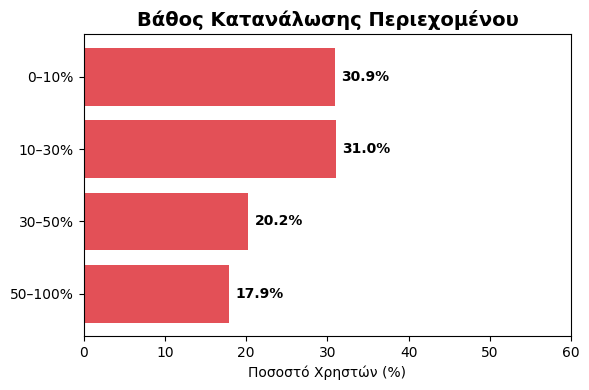

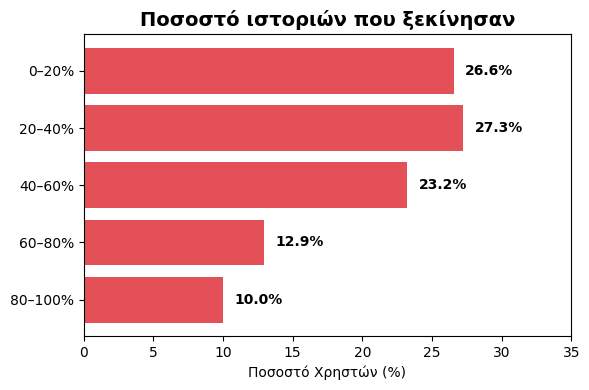

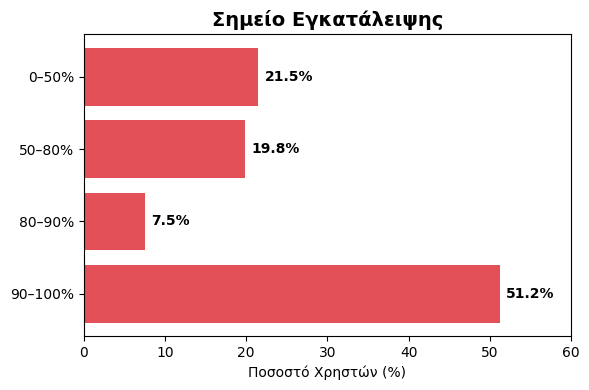

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Custom brackets per metric
# -----------------------------
custom_bins = {
    "depth_ratio": {
        "bins": [0, 0.10, 0.30, 0.50, 1.00],
        "labels": ["0–10%", "10–30%", "30–50%", "50–100%"],
        "title": "Βάθος Κατανάλωσης Περιεχομένου",
        "xlim": 60,
        "filename": "depth_ratio_custom.png"
    },
    "pct_touched": {
        "bins": [0, 0.20, 0.40, 0.60, 0.80, 1.00],
        "labels": ["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"],
        "title": "Ποσοστό ιστοριών που ξεκίνησαν",
        "xlim": 35,
        "filename": "pct_touched_custom.png"
    },
    "dropoff": {
        "bins": [0, 0.50, 0.80, 0.90, 1.00],
        "labels": ["0–50%", "50–80%", "80–90%", "90–100%"],
        "title": "Σημείο Εγκατάλειψης",
        "xlim": 60,
        "filename": "dropoff_custom.png"
    }
}

def get_bucket_percentages(df, col, bins, labels):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )
    out["pct_users"] = out["n_users"] / out["n_users"].sum() * 100
    return out

# -----------------------------
# 2. Create the 3 charts
# -----------------------------
for metric, cfg in custom_bins.items():
    stats = get_bucket_percentages(
        user_stats,
        metric,
        cfg["bins"],
        cfg["labels"]
    )

    buckets = stats["bracket"].tolist()
    values = stats["pct_users"].tolist()

    fig, ax = plt.subplots(figsize=(6, 4))

    bars = ax.barh(buckets, values, color="#e35057")
    ax.invert_yaxis()

    ax.set_xlim(0, cfg["xlim"])
    ax.set_title(cfg["title"], fontsize=14, fontweight="bold")
    ax.set_xlabel("Ποσοστό Χρηστών (%)")

    for i, v in enumerate(values):
        ax.text(v + 0.8, i, f"{v:.1f}%", va='center', fontweight="bold")

    plt.tight_layout()
    plt.savefig(cfg["filename"], dpi=300, bbox_inches="tight")
    plt.show()

In [120]:
story_path = BASE_DIR / "data/clean/story_order.parquet"

In [121]:
Story_order = pd.read_parquet(story_path)

In [122]:
# 1) keep only story_start events and attach story order
story_start_seq = (
    ANDROID_events.loc[ANDROID_events["event_name"] == "story_start",
                       ["journey_id", "user_pseudo_id", "tour_id", "story_id", "event_datetime"]]
    .merge(
        Story_order[["tour_id", "story_id", "story_position"]],
        on=["tour_id", "story_id"],
        how="left"
    )
    .sort_values(["journey_id", "event_datetime"])
)

# 2) previous story position inside each journey
story_start_seq["prev_story_position"] = (
    story_start_seq.groupby("journey_id")["story_position"].shift(1)
)

# 3) transition difference
story_start_seq["position_diff"] = (
    story_start_seq["story_position"] - story_start_seq["prev_story_position"]
)

# 4) flag sequential transitions (+1 means exact intended next story)
story_start_seq["is_sequential"] = (story_start_seq["position_diff"] == 1).astype(int)

# 5) count transitions per journey
journey_transitions = (
    story_start_seq.loc[story_start_seq["prev_story_position"].notna()]
    .groupby("journey_id")
    .agg(
        total_transitions=("is_sequential", "size"),
        sequential_transitions=("is_sequential", "sum")
    )
    .reset_index()
)

# 6) sequential order metric
journey_transitions["sequential_ratio"] = (
    journey_transitions["sequential_transitions"] /
    journey_transitions["total_transitions"]
)

# 7) attach journey identity
journey_sequentiality = (
    ANDROID_events[["journey_id", "user_pseudo_id", "tour_id"]]
    .drop_duplicates()
    .merge(journey_transitions, on="journey_id", how="left")
)

# optional: inspect
journey_sequentiality.head()

,journey_id,user_pseudo_id,tour_id,total_transitions,sequential_transitions,sequential_ratio
0,12146,c7f26129dd892cb7292f6283113726ad,107,81.0,62.0,0.765432
1,12147,c7f26129dd892cb7292f6283113726ad,226,NaN,NaN,NaN
2,840,0e1e29466bf2de31e00fe7a989673c99,822,1.0,0.0,0.000000
3,841,0e1e29466bf2de31e00fe7a989673c99,822,120.0,60.0,0.500000
4,7295,767fa15a9558b669f47d8e67e719918c,284,110.0,14.0,0.127273


In [123]:
journey_sequentiality = journey_sequentiality.loc[
    journey_sequentiality["total_transitions"].notna()
]

In [124]:
journey_stats = journey_stats.loc[
    journey_stats["journey_id"].isin(journey_sequentiality["journey_id"])
]

In [ ]:
# journey_stats = journey_stats.merge(
#     journey_sequentiality[[
#         "journey_id",
#         "total_transitions",
#         "sequential_transitions",
#         "sequential_ratio"
#     ]],
#     on="journey_id",
#     how="left"
# )

In [125]:
# story_ids completed inside each journey
completed_in_journey = (
    ANDROID_events.loc[ANDROID_events["event_name"] == "story_completed", ["journey_id", "story_id"]]
    .drop_duplicates()
    .assign(completed_in_journey=1)
)

# add completion flag to the story_start sequence table
story_start_seq = story_start_seq.merge(
    completed_in_journey,
    on=["journey_id", "story_id"],
    how="left"
)

story_start_seq["completed_in_journey"] = story_start_seq["completed_in_journey"].fillna(0).astype(int)

# completed sequential transition:
# current story is sequential (+1 from previous) AND current story got completed
story_start_seq["is_completed_sequential"] = (
    (story_start_seq["position_diff"] == 1) &
    (story_start_seq["completed_in_journey"] == 1)
).astype(int)

# aggregate per journey
journey_seq_completed = (
    story_start_seq.loc[story_start_seq["prev_story_position"].notna()]
    .groupby("journey_id")
    .agg(
        completed_sequential_transitions=("is_completed_sequential", "sum")
    )
    .reset_index()
)

# ratio
journey_seq_completed = journey_seq_completed.merge(
    journey_sequentiality[["journey_id", "total_transitions"]],
    on="journey_id",
    how="left"
)

journey_seq_completed["sequential_completed_ratio"] = (
    journey_seq_completed["completed_sequential_transitions"] /
    journey_seq_completed["total_transitions"]
)

# # merge into journey_stats
# journey_stats = journey_stats.merge(
#     journey_seq_completed[[
#         "journey_id",
#         "completed_sequential_transitions",
#         "sequential_completed_ratio"
#     ]],
#     on="journey_id",
#     how="left"
# )

In [126]:
# rebuild previous story_id as well
story_start_seq = story_start_seq.sort_values(["journey_id", "event_datetime"]).copy()

story_start_seq["prev_story_id"] = (
    story_start_seq.groupby("journey_id")["story_id"].shift(1)
)

story_start_seq["prev_story_position"] = (
    story_start_seq.groupby("journey_id")["story_position"].shift(1)
)

story_start_seq["position_diff"] = (
    story_start_seq["story_position"] - story_start_seq["prev_story_position"]
)

# keep only rows that are exact sequential transitions
seq_only = story_start_seq.loc[
    story_start_seq["position_diff"] == 1,
    ["journey_id", "prev_story_id", "story_id", "completed_in_journey"]
].copy()

# DISTINCT sequential transitions
distinct_seq = (
    seq_only
    .drop_duplicates(subset=["journey_id", "prev_story_id", "story_id"])
)

# count distinct sequential transitions per journey
distinct_seq_counts = (
    distinct_seq
    .groupby("journey_id")
    .size()
    .reset_index(name="distinct_sequential_transitions")
)

# count DISTINCT completed sequential transitions per journey
distinct_completed_seq_counts = (
    distinct_seq.loc[distinct_seq["completed_in_journey"] == 1]
    .groupby("journey_id")
    .size()
    .reset_index(name="distinct_completed_sequential_transitions")
)

# # merge into journey_stats
# journey_stats = journey_stats.drop(
#     columns=[
#         "distinct_sequential_transitions",
#         "distinct_completed_sequential_transitions",
#         "global_sequential_coverage",
#         "global_completed_sequential_coverage"
#     ],
#     errors="ignore"
# )

# journey_stats = journey_stats.merge(
#     distinct_seq_counts,
#     on="journey_id",
#     how="left"
# )

# journey_stats = journey_stats.merge(
#     distinct_completed_seq_counts,
#     on="journey_id",
#     how="left"
# )

# journey_stats["distinct_sequential_transitions"] = (
#     journey_stats["distinct_sequential_transitions"].fillna(0)
# )

# journey_stats["distinct_completed_sequential_transitions"] = (
#     journey_stats["distinct_completed_sequential_transitions"].fillna(0)
# )

# # max possible distinct sequential transitions in a full tour
# journey_stats["max_possible_transitions"] = journey_stats["total_stories"] - 1

# # corrected global ratios
# journey_stats["global_sequential_coverage"] = (
#     journey_stats["distinct_sequential_transitions"] /
#     journey_stats["max_possible_transitions"]
# )

# journey_stats["global_completed_sequential_coverage"] = (
#     journey_stats["distinct_completed_sequential_transitions"] /
#     journey_stats["max_possible_transitions"]
# )

In [127]:
# keep only journeys that exist in journey_stats
jump_base = story_start_seq.loc[
    story_start_seq["journey_id"].isin(journey_stats["journey_id"])
].copy()

# keep only actual transitions
jump_transitions = jump_base.loc[
    jump_base["prev_story_position"].notna()
].copy()

# define jump types exactly like the old code
jump_transitions["is_forward_jump"] = (jump_transitions["position_diff"] > 1).astype(int)
jump_transitions["is_backward"] = (jump_transitions["position_diff"] < 0).astype(int)

# aggregate per journey
journey_jump_stats = (
    jump_transitions
    .groupby("journey_id")
    .agg(
        pct_forward_jump=("is_forward_jump", "mean"),
        pct_backward=("is_backward", "mean"),
        avg_jump_distance=("position_diff", "mean")
    )
    .reset_index()
)

journey_jump_stats.head()

,journey_id,pct_forward_jump,pct_backward,avg_jump_distance
0,0,0.190476,0.178571,0.785714
1,2,0.025000,0.025000,0.850000
2,4,0.000000,0.200000,-0.200000
3,5,0.142857,0.268908,-0.050420
4,6,0.222222,0.222222,1.111111


In [128]:
journey_jump_stats.describe()

,journey_id,pct_forward_jump,pct_backward,avg_jump_distance
count,10482.000000,10482.000000,10482.000000,10482.000000
mean,7850.387426,0.261531,0.192557,0.959302
std,4529.989259,0.188638,0.170151,4.188813
min,0.000000,0.000000,0.000000,-76.000000
25%,3918.500000,0.129558,0.072727,0.200000
50%,7853.500000,0.240000,0.166667,0.741573
75%,11764.750000,0.367347,0.269231,1.211722
max,15732.000000,1.000000,1.000000,100.000000


In [129]:
user_stats.columns

Index(['user_pseudo_id', 'n_journeys', 'distinct_stories_touched',
       'distinct_stories_completed', 'total_times_completed',
       'max_story_completed_position', 'dropoff_position', 'total_stories',
       'depth_ratio', 'max_depth', 'dropoff', 'total_transitions',
       'sequential_transitions', 'sequential_ratio',
       'completed_sequential_transitions', 'sequential_completed_ratio',
       'distinct_sequential_transitions',
       'distinct_completed_sequential_transitions', 'max_possible_transitions',
       'global_sequential_coverage', 'global_completed_sequential_coverage',
       'interactivity_pct', 'pct_touched'],
      dtype='str')

In [130]:
import pandas as pd
import numpy as np

labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)]

def bracket_stats_10_users(df, col):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    bins = np.linspace(0, 1, 11)

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )

    out["pct_users"] = (out["n_users"] / out["n_users"].sum() * 100).round(1)
    out["metric"] = col

    return out[["metric", "bracket", "n_users", "pct_users"]]

global_seq_stats = bracket_stats_10_users(user_stats, "global_sequential_coverage")
global_completed_seq_stats = bracket_stats_10_users(user_stats, "global_completed_sequential_coverage")

global_seq_stats
global_completed_seq_stats

,metric,bracket,n_users,pct_users
0,global_completed_sequential_coverage,0-10%,3499,43.9
1,global_completed_sequential_coverage,10-20%,1587,19.9
2,global_completed_sequential_coverage,20-30%,1134,14.2
3,global_completed_sequential_coverage,30-40%,768,9.6
4,global_completed_sequential_coverage,40-50%,393,4.9
5,global_completed_sequential_coverage,50-60%,250,3.1
6,global_completed_sequential_coverage,60-70%,159,2.0
7,global_completed_sequential_coverage,70-80%,85,1.1
8,global_completed_sequential_coverage,80-90%,65,0.8
9,global_completed_sequential_coverage,90-100%,25,0.3


In [131]:
seq_stats = pd.concat([
    bracket_stats_10_users(user_stats, "global_sequential_coverage"),
    bracket_stats_10_users(user_stats, "global_completed_sequential_coverage")
], ignore_index=True)

seq_stats

,metric,bracket,n_users,pct_users
0,global_sequential_coverage,0-10%,2192,27.5
1,global_sequential_coverage,10-20%,1560,19.6
2,global_sequential_coverage,20-30%,1357,17.0
3,global_sequential_coverage,30-40%,1149,14.4
4,global_sequential_coverage,40-50%,611,7.7
5,global_sequential_coverage,50-60%,385,4.8
6,global_sequential_coverage,60-70%,297,3.7
7,global_sequential_coverage,70-80%,212,2.7
8,global_sequential_coverage,80-90%,104,1.3
9,global_sequential_coverage,90-100%,98,1.2


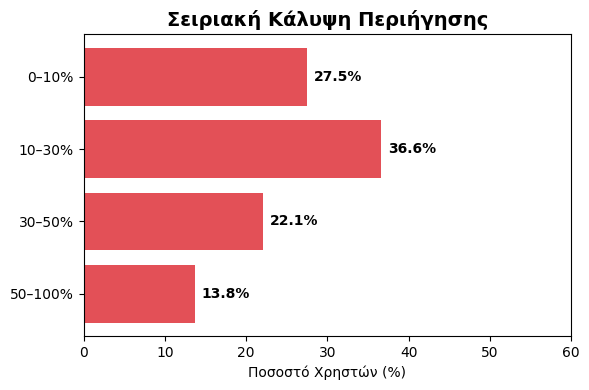

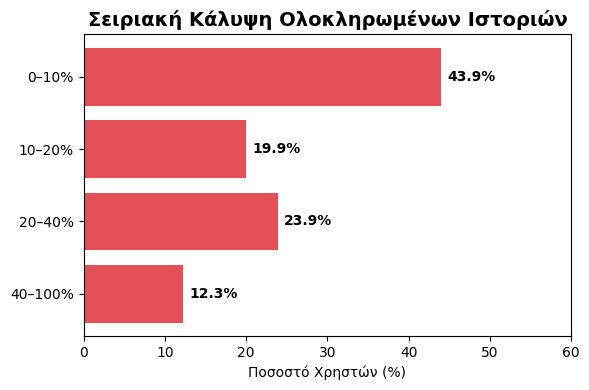

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Custom brackets per metric
# -----------------------------
custom_bins = {
    "global_sequential_coverage": {
        "bins": [0, 0.10, 0.30, 0.50, 1.00],
        "labels": ["0–10%", "10–30%", "30–50%", "50–100%"],
        "title": "Σειριακή Κάλυψη Περιήγησης",
        "xlim": 60,
        "filename": "global_sequential_coverage_custom.png"
    },
    "global_completed_sequential_coverage": {
        "bins": [0, 0.10, 0.20, 0.40, 1.00],
        "labels": ["0–10%", "10–20%", "20–40%", "40–100%"],
        "title": "Σειριακή Κάλυψη Ολοκληρωμένων Ιστοριών",
        "xlim": 60,
        "filename": "global_completed_sequential_coverage_custom.png"
    }
}

def get_bucket_percentages(df, col, bins, labels):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )
    out["pct_users"] = out["n_users"] / out["n_users"].sum() * 100
    return out

# -----------------------------
# 2. Create the 2 charts
# -----------------------------
for metric, cfg in custom_bins.items():
    stats = get_bucket_percentages(
        user_stats,
        metric,
        cfg["bins"],
        cfg["labels"]
    )

    buckets = stats["bracket"].tolist()
    values = stats["pct_users"].tolist()

    fig, ax = plt.subplots(figsize=(6, 4))

    bars = ax.barh(buckets, values, color="#e35057")
    ax.invert_yaxis()

    ax.set_xlim(0, cfg["xlim"])
    ax.set_title(cfg["title"], fontsize=14, fontweight="bold")
    ax.set_xlabel("Ποσοστό Χρηστών (%)")

    for i, v in enumerate(values):
        ax.text(v + 0.8, i, f"{v:.1f}%", va='center', fontweight="bold")

    plt.tight_layout()
    plt.savefig(cfg["filename"], dpi=300, bbox_inches="tight")
    plt.show()

In [133]:
import pandas as pd
import numpy as np

labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)]

def bracket_stats_10_users(df, col):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    bins = np.linspace(0, 1, 11)

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )

    out["pct_users"] = (out["n_users"] / out["n_users"].sum() * 100).round(1)
    out["metric"] = col

    return out[["metric", "bracket", "n_users", "pct_users"]]

interactivity_stats = bracket_stats_10_users(user_stats, "interactivity_pct")
interactivity_stats

,metric,bracket,n_users,pct_users
0,interactivity_pct,0-10%,5586,70.1
1,interactivity_pct,10-20%,1792,22.5
2,interactivity_pct,20-30%,435,5.5
3,interactivity_pct,30-40%,105,1.3
4,interactivity_pct,40-50%,33,0.4
5,interactivity_pct,50-60%,9,0.1
6,interactivity_pct,60-70%,3,0.0
7,interactivity_pct,70-80%,2,0.0
8,interactivity_pct,80-90%,0,0.0
9,interactivity_pct,90-100%,0,0.0


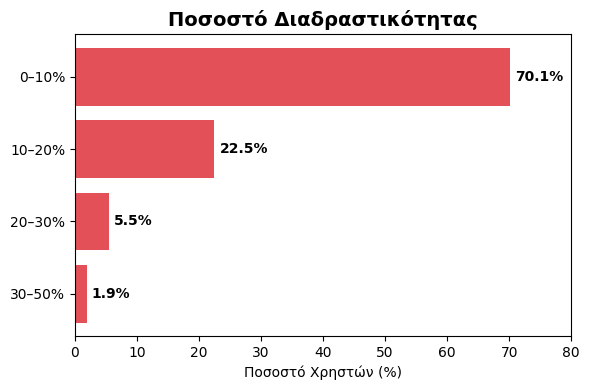

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

custom_bins = {
    "interactivity_pct": {
        "bins": [0, 0.10, 0.20, 0.30, 1.00],
        "labels": ["0–10%", "10–20%", "20–30%", "30–50%"],
        "title": "Ποσοστό Διαδραστικότητας",
        "xlim": 80,
        "filename": "interactivity_pct_custom.png"
    }
}

def get_bucket_percentages(df, col, bins, labels):
    s = df[col].copy()
    s = s[(s >= 0) & (s <= 1)]

    cats = pd.cut(
        s,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    out = (
        cats.value_counts(sort=False)
        .rename_axis("bracket")
        .reset_index(name="n_users")
    )
    out["pct_users"] = out["n_users"] / out["n_users"].sum() * 100
    return out

for metric, cfg in custom_bins.items():
    stats = get_bucket_percentages(
        user_stats,
        metric,
        cfg["bins"],
        cfg["labels"]
    )

    buckets = stats["bracket"].tolist()
    values = stats["pct_users"].tolist()

    fig, ax = plt.subplots(figsize=(6, 4))

    bars = ax.barh(buckets, values, color="#e35057")
    ax.invert_yaxis()

    ax.set_xlim(0, cfg["xlim"])
    ax.set_title(cfg["title"], fontsize=14, fontweight="bold")
    ax.set_xlabel("Ποσοστό Χρηστών (%)")

    for i, v in enumerate(values):
        ax.text(v + 0.8, i, f"{v:.1f}%", va='center', fontweight="bold")

    plt.tight_layout()
    plt.savefig(cfg["filename"], dpi=300, bbox_inches="tight")
    plt.show()

In [135]:
import pandas as pd
from IPython.display import display

# ----------------------------------
# Fake dataframe σαν το cluster table
# ----------------------------------
cluster_profile = pd.DataFrame({
    "depth_ratio": [0.242, 0.627, 0.069],
    "pct_touched": [0.408, 0.761, 0.148],
    "max_depth": [0.739, 0.920, 0.212],
    "sequential_completed": [0.146, 0.459, 0.040],
    "interactivity_pct": [0.079, 0.068, 0.096],
    "n_journeys": [1.370, 1.203, 1.316]
}, index=[0, 1, 2])

cluster_profile.index.name = "cluster"

# ----------------------------------
# Metrics + labels
# ----------------------------------
METRICS = [
    ("depth_ratio", "Ολοκλήρωση tour (%)"),
    ("pct_touched", "Ποσοστό Περιήγησης (%)"),
    ("max_depth", "Μέγιστη Πρόοδος (%)"),
    ("sequential_completed", "Διαδοχική ακρόαση (%)"),
    ("interactivity_pct", "Ποσοστό Διαδραστικότητας (%)"),
]

def styled_cluster_card(cluster_profile, c, title=None):
    rows = []
    for col, label in METRICS:
        val = float(cluster_profile.loc[c, col])
        val *= 100
        rows.append((label, val))

    df = pd.DataFrame(rows, columns=["Δείκτης", "Τιμή (%)"])

    strongest = "#e35057"
    lighter = "#ee8c91"

    def bar_formatter(val):
        width = max(0, min(100, float(val)))
        return (
            "background: "
            f"linear-gradient(90deg, "
            f"{strongest} 0%, "
            f"{lighter} {width*0.6}%, "
            f"white {width}%);"
            "color: black;"
            "font-weight: 700;"
            "padding: 2px 6px;"
            "white-space: nowrap;"
        )

    caption = title if title else f"Cluster {c}"

    styled = (
        df.style
        .hide(axis="index")
        .set_caption(caption)
        .set_properties(**{
            "border": "1px solid black",
            "text-align": "left",
            "background-color": "white",
            "color": "black",
            "font-size": "12px",
            "padding": "3px 6px"
        })
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "800"),
                ("text-align", "center"),
                ("padding", "2px 0 8px 0"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("text-align", "left"),
                ("font-weight", "800"),
                ("font-size", "12px"),
                ("border", "1px solid black"),
                ("padding", "3px 6px"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid black"),
                ("padding", "3px 6px"),
            ]},
        ])
        .format({"Τιμή (%)": "{:.2f}%"})
        .apply(lambda col: [bar_formatter(v) for v in col] if col.name == "Τιμή (%)"
               else ["background-color: white;"] * len(col))
    )

    return styled

In [136]:
display(styled_cluster_card(cluster_profile, 0, "Cluster 0"))
display(styled_cluster_card(cluster_profile, 1, "Cluster 1"))
display(styled_cluster_card(cluster_profile, 2, "Cluster 2"))

Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),24.20%
Ποσοστό Περιήγησης (%),40.80%
Μέγιστη Πρόοδος (%),73.90%
Διαδοχική ακρόαση (%),14.60%
Ποσοστό Διαδραστικότητας (%),7.90%


Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),62.70%
Ποσοστό Περιήγησης (%),76.10%
Μέγιστη Πρόοδος (%),92.00%
Διαδοχική ακρόαση (%),45.90%
Ποσοστό Διαδραστικότητας (%),6.80%


Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),6.90%
Ποσοστό Περιήγησης (%),14.80%
Μέγιστη Πρόοδος (%),21.20%
Διαδοχική ακρόαση (%),4.00%
Ποσοστό Διαδραστικότητας (%),9.60%


In [ ]:
import dataframe_image as dfi

dfi.export(styled_cluster_card(cluster_profile, 0, "Cluster 0"), "cluster_0_card.png")
dfi.export(styled_cluster_card(cluster_profile, 1, "Cluster 1"), "cluster_1_card.png")
dfi.export(styled_cluster_card(cluster_profile, 2, "Cluster 2"), "cluster_2_card.png")

In [138]:
import dataframe_image as dfi

dfi.export(
    styled_cluster_card(cluster_profile, 0, title="Περιστασιακοί / Surface Users"),
    "cluster_0.png",
    table_conversion="matplotlib"
)

dfi.export(
    styled_cluster_card(cluster_profile, 1, title="Πλήρεις Ακροατές"),
    "cluster_1.png",
    table_conversion="matplotlib"
)

dfi.export(
    styled_cluster_card(cluster_profile, 2, title="Εξερευνητές"),
    "cluster_2.png",
    table_conversion="matplotlib"
)


ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 14.52%, white 24.2%) [38:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 24.48%, white 40.8%) [51:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 44.34%, white 73.9%) [64:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 8.76%, white 14.6%) [77:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 4.74%, white 7.9%) [90:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 37.62%, white 62.7%) [38:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 45.66%, white 76.1%) [51:3: background]
ER

In [139]:
dfi.export(
    styled_cluster_card(cluster_profile, 0, title="Περιστασιακοί / Surface Users"),
    "cluster_0.png",
    table_conversion="matplotlib"
)

dfi.export(
    styled_cluster_card(cluster_profile, 1, title="Πλήρεις Ακροατές"),
    "cluster_1.png",
    table_conversion="matplotlib"
)

dfi.export(
    styled_cluster_card(cluster_profile, 2, title="Εξερευνητές"),
    "cluster_2.png",
    table_conversion="matplotlib"
)

ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 14.52%, white 24.2%) [38:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 24.48%, white 40.8%) [51:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 44.34%, white 73.9%) [64:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 8.76%, white 14.6%) [77:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 4.74%, white 7.9%) [90:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 37.62%, white 62.7%) [38:3: background]
ERROR	Property: Invalid value for "CSS Level 2.1" property: linear-gradient(90deg, #e35057 0%, #ee8c91 45.66%, white 76.1%) [51:3: background]
ER

In [140]:
display(styled_cluster_card(cluster_profile, 0, title="Περιστασιακοί / Surface Users"))
display(styled_cluster_card(cluster_profile, 1, title="Πλήρεις Ακροατές"))
display(styled_cluster_card(cluster_profile, 2, title="Εξερευνητές"))

Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),24.20%
Ποσοστό Περιήγησης (%),40.80%
Μέγιστη Πρόοδος (%),73.90%
Διαδοχική ακρόαση (%),14.60%
Ποσοστό Διαδραστικότητας (%),7.90%


Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),62.70%
Ποσοστό Περιήγησης (%),76.10%
Μέγιστη Πρόοδος (%),92.00%
Διαδοχική ακρόαση (%),45.90%
Ποσοστό Διαδραστικότητας (%),6.80%


Δείκτης,Τιμή (%)
Ολοκλήρωση tour (%),6.90%
Ποσοστό Περιήγησης (%),14.80%
Μέγιστη Πρόοδος (%),21.20%
Διαδοχική ακρόαση (%),4.00%
Ποσοστό Διαδραστικότητας (%),9.60%


In [143]:
dfi.export(
    styled_cluster_card(cluster_profile, 0, title="Εξερευνητές"),
    "cluster0.png",
     table_conversion="chrome"
)

dfi.export(
    styled_cluster_card(cluster_profile, 1, title="Πλήρεις Ακροατές"),
    "cluster1.png",
     table_conversion="chrome"
)

dfi.export(
    styled_cluster_card(cluster_profile, 2, title="Περιστασιακοί / Surface Users"),
    "cluster2.png",
     table_conversion="chrome"
)

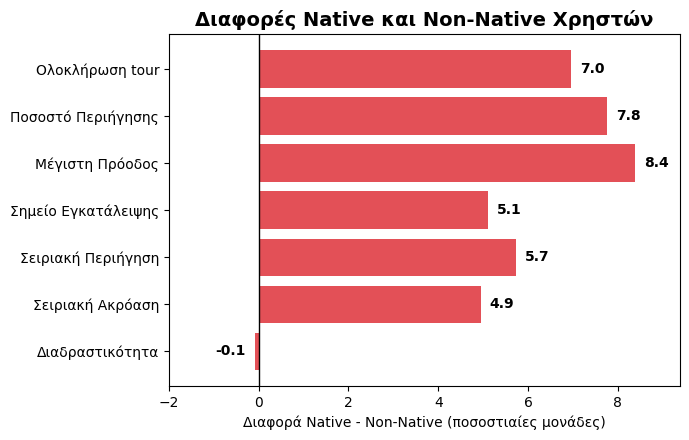

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# metrics του clustering + ελληνικές ετικέτες
metric_labels = {
    "depth_ratio_diff": "Ολοκλήρωση tour",
    "pct_touched_diff": "Ποσοστό Περιήγησης",
    "max_depth_diff": "Μέγιστη Πρόοδος",
    "dropoff_diff": "Σημείο Εγκατάλειψης",
    "global_sequential_coverage_diff": "Σειριακή Περιήγηση",
    "global_completed_sequential_coverage_diff": "Σειριακή Ακρόαση",
    "interactivity_pct_diff": "Διαδραστικότητα"
}

# κράτα μόνο αυτά
plot_df = within_tour_avg_diff[
    within_tour_avg_diff["metric"].isin(metric_labels.keys())
].copy()

# labels
plot_df["label"] = plot_df["metric"].map(metric_labels)

# σειρά εμφάνισης (όπως τα θες)
order = [
    "depth_ratio_diff",
    "pct_touched_diff",
    "max_depth_diff",
    "dropoff_diff",
    "global_sequential_coverage_diff",
    "global_completed_sequential_coverage_diff",
    "interactivity_pct_diff"
]

plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=order, ordered=True)
plot_df = plot_df.sort_values("metric")

# αν θες σε ποσοστιαίες μονάδες
plot_df["value_pct"] = plot_df["avg_native_minus_non_native"] * 100

buckets = plot_df["label"].tolist()
values = plot_df["value_pct"].tolist()

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.barh(buckets, values, color="#e35057")
ax.invert_yaxis()

# όρια άξονα ώστε να χωράνε και μικρές αρνητικές τιμές
xmin = min(values)
xmax = max(values)
ax.set_xlim(min(-2, xmin - 1), xmax + 1)

ax.set_title("Διαφορές Native και Non-Native Χρηστών", fontsize=14, fontweight="bold")
ax.set_xlabel("Διαφορά Native - Non-Native (ποσοστιαίες μονάδες)")
ax.axvline(0, color="black", linewidth=1)

# labels πάνω στις μπάρες
for i, v in enumerate(values):
    if v >= 0:
        ax.text(v + 0.2, i, f"{v:.1f}", va='center', fontweight="bold")
    else:
        ax.text(v - 0.2, i, f"{v:.1f}", va='center', ha='right', fontweight="bold")

plt.tight_layout()
plt.savefig("native_vs_non_native_clustering_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [149]:
import pandas as pd
from IPython.display import display
import dataframe_image as dfi

# ----------------------------------
# Fake one-row dataframe for successful tours
# ----------------------------------
successful_tours_profile = pd.DataFrame({
    "depth_ratio": [0.350112],
    "pct_touched": [0.537288],
    "max_depth": [0.659937],
    "sequential_completed": [0.254422],
    "interactivity_pct": [0.05],   # βάλε την πραγματική τιμή αν την έχεις
}, index=[0])

# ----------------------------------
# ίδιο style function όπως πριν
# ----------------------------------
METRICS = [
    ("depth_ratio", "Ολοκλήρωση tour (%)"),
    ("pct_touched", "Ποσοστό Περιήγησης (%)"),
    ("max_depth", "Μέγιστη Πρόοδος (%)"),
    ("sequential_completed", "Διαδοχική ακρόαση (%)"),
    ("interactivity_pct", "Ποσοστό Διαδραστικότητας (%)"),
]

def styled_cluster_card(cluster_profile, c, title=None):
    rows = []
    for col, label in METRICS:
        val = float(cluster_profile.loc[c, col])
        val *= 100
        rows.append((label, val))

    df = pd.DataFrame(rows, columns=["Δείκτης", "Τιμή (%)"])

    strongest = "#e35057"
    lighter = "#ee8c91"

    def bar_formatter(val):
        width = max(0, min(100, float(val)))
        return (
            "background: "
            f"linear-gradient(90deg, "
            f"{strongest} 0%, "
            f"{lighter} {width*0.6}%, "
            f"white {width}%);"
            "color: black;"
            "font-weight: 700;"
            "padding: 2px 6px;"
            "white-space: nowrap;"
        )

    caption = title if title else f"Cluster {c}"

    styled = (
        df.style
        .hide(axis="index")
        .set_caption(caption)
        .set_properties(**{
            "border": "1px solid black",
            "text-align": "left",
            "background-color": "white",
            "color": "black",
            "font-size": "12px",
            "padding": "3px 6px"
        })
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "800"),
                ("text-align", "center"),
                ("padding", "2px 0 8px 0"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("text-align", "left"),
                ("font-weight", "800"),
                ("font-size", "12px"),
                ("border", "1px solid black"),
                ("padding", "3px 6px"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid black"),
                ("padding", "3px 6px"),
            ]},
        ])
        .format({"Τιμή (%)": "{:.2f}%"})
        .apply(lambda col: [bar_formatter(v) for v in col] if col.name == "Τιμή (%)"
               else ["background-color: white;"] * len(col))
    )

    return styled

In [150]:
dfi.export(
    styled_cluster_card(successful_tours_profile, 0, title="Succesfull tours"),
    "successful_tours.png",
    table_conversion="chrome"
)